### описание

1) По аналогии с функцией best_continious_split, напишите функцию best_categorical_split (которая перебирает все возможные комбинации категорий для сплита), если количество категорий больше 5, то использует стратегию one vs rest

P.S Возможно best_continious_split придётся переписать, убрав предположение о том, что все значения в фиче разные

2) Реализовать собственный класс дерева решения для бинарной классификации

3) Протестировать его на датасете одобрения кредита (approval rate)

4) Сравнить качество работы модели при разных критериях разбиения (gini vs entropy)

5) Сравнить качество с sklearn деревом

In [131]:
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
)

In [132]:
RANDOM_STATE = 69
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

In [133]:
def show_metrics(true, preds, probas=None, precision=4):
    ac_score = accuracy_score(true, preds)
    pr_score = precision_score(true, preds)
    rc_score = recall_score(true, preds)
    f1_sc = f1_score(true, preds)
    roc_auc_pr = roc_auc_score(true, preds)
    roc_auc_proba = roc_auc_score(true, probas) if probas is not None else None

    print(f"Accuracy: {ac_score:.{precision}f}")
    print(f"Precision: {pr_score:.{precision}f}")
    print(f"Recall: {rc_score:.{precision}f}")
    print(f"F1 Score: {f1_sc:.{precision}f}")
    print(f"ROC AUC (preds): {roc_auc_pr:.{precision}f}")
    if roc_auc_proba is not None:
        print(f"ROC AUC (probas): {roc_auc_proba:.{precision}f}")
    else:
        print("ROC AUC (probas): Not applicable")

    return {
        "accuracy": ac_score,
        "precision": pr_score,
        "recall": rc_score,
        "f1_score": f1_sc,
        "roc_auc_preds": roc_auc_pr,
        "roc_auc_probas": roc_auc_proba,
    }

### 1: best_continios_split, best_categorical_split

In [134]:
def best_continios_split(values, targets, criterion, plot=False):
    sorted_pairs = sorted(list(zip(values, targets)), key=lambda x: x[0])

    n = len(sorted_pairs)
    p = sum(targets) / n
    node_criterion = criterion(p)

    best_criterion = node_criterion
    best_split = None

    split_vals = []
    criterion_vals = []

    ones = 0
    total_ones = sum(targets)

    for i in range(1, len(sorted_pairs)):
        split_val = (sorted_pairs[i - 1][0] + sorted_pairs[i][0]) / 2
        ones += sorted_pairs[i - 1][1]

        p_left = ones / i
        p_right = (total_ones - ones) / (n - i)

        split_criterion = i / n * criterion(p_left) + (n - i) / n * criterion(p_right)

        split_vals.append(split_val)
        criterion_vals.append(split_criterion)

        if split_criterion < best_criterion:
            best_criterion = split_criterion
            best_split = split_val

    if plot:
        plt.plot(split_vals, criterion_vals)

    return (best_split, best_criterion)

In [135]:
def best_categorical_split(values, targets, criterion, max_categories=5):
    unique_cats = list(set(values))
    n = len(values)
    p = sum(targets) / n
    node_criterion = criterion(p)

    best_criterion = node_criterion
    best_split = None

    if len(unique_cats) <= max_categories:
        possible_splits = []
        for i in range(1, len(unique_cats)):
            possible_splits.extend(combinations(unique_cats, i))

        for split_cats in possible_splits:
            split_cats = set(split_cats)
            left_indices = [i for i, v in enumerate(values) if v in split_cats]
            right_indices = [i for i, v in enumerate(values) if v not in split_cats]

            if not left_indices or not right_indices:
                continue

            left_targets = [targets[i] for i in left_indices]
            right_targets = [targets[i] for i in right_indices]

            p_left = sum(left_targets) / len(left_targets)
            p_right = sum(right_targets) / len(right_targets)

            split_criterion = (len(left_targets) / n) * criterion(p_left) + (
                len(right_targets) / n
            ) * criterion(p_right)

            if split_criterion < best_criterion:
                best_criterion = split_criterion
                best_split = split_cats

    else:
        for cat in unique_cats:
            split_cats = {cat}
            left_indices = [i for i, v in enumerate(values) if v in split_cats]
            right_indices = [i for i, v in enumerate(values) if v not in split_cats]

            if not left_indices or not right_indices:
                continue

            left_targets = [targets[i] for i in left_indices]
            right_targets = [targets[i] for i in right_indices]

            p_left = sum(left_targets) / len(left_targets)
            p_right = sum(right_targets) / len(right_targets)

            split_criterion = (len(left_targets) / n) * criterion(p_left) + (
                len(right_targets) / n
            ) * criterion(p_right)

            if split_criterion < best_criterion:
                best_criterion = split_criterion
                best_split = split_cats

    return (best_split, best_criterion)

### 2: дерево для бинарной классификации

In [136]:
class MyDecisionTreeClassifier:
    def __init__(self, criterion="gini", max_leaves=None, min_samples_leaf=1):
        self.criterion = criterion
        self.max_leaves = max_leaves
        self.min_samples_leaf = min_samples_leaf
        self.root = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "answer": None,
            "categorical": False,
            "categories": None,
        }
        self.feature_names = None
        self.n_leaves = 0

    def _criterion_func(self, p):
        if self.criterion == "gini":
            return p * (1 - p) * 2
        else:
            if p == 0 or p == 1:
                return 0
            return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

    def _is_categorical(self, values):
        return isinstance(values[0], (str, bool)) or len(set(values)) < 10

    def _split_data(
        self, X, y, feature_idx, threshold, categorical=False, categories=None
    ):
        if categorical:
            mask = np.array([x[feature_idx] in categories for x in X])
        else:
            mask = np.array([x[feature_idx] <= threshold for x in X])

        X_left, y_left = X[mask], y[mask]
        X_right, y_right = X[~mask], y[~mask]

        return X_left, y_left, X_right, y_right

    def _build_tree(self, X, y, depth=0, node=None):
        if node is None:
            node = self.root

        if (
            len(X) < 2 * self.min_samples_leaf
            or len(set(y)) == 1
            or (self.max_leaves is not None and self.n_leaves >= self.max_leaves)
        ):
            self.n_leaves += 1
            node["answer"] = Counter(y).most_common(1)[0][0]
            return

        best_feature = None
        best_threshold = None
        best_criterion_val = float("inf")
        is_categorical = False
        categories = None

        for feature_idx in range(X.shape[1]):
            values = X[:, feature_idx]
            if self._is_categorical(values):
                split_info = best_categorical_split(values, y, self._criterion_func)
                if split_info[0] is not None and split_info[1] < best_criterion_val:
                    best_feature = feature_idx
                    best_threshold = None
                    best_criterion_val = split_info[1]
                    is_categorical = True
                    categories = split_info[0]
            else:
                split_info = best_continios_split(values, y, self._criterion_func)
                if split_info[0] is not None and split_info[1] < best_criterion_val:
                    best_feature = feature_idx
                    best_threshold = split_info[0]
                    best_criterion_val = split_info[1]
                    is_categorical = False
                    categories = None

        if best_feature is None:
            self.n_leaves += 1
            node["answer"] = Counter(y).most_common(1)[0][0]
            return

        node["feature_name"] = (
            self.feature_names[best_feature]
            if self.feature_names is not None
            else best_feature
        )
        node["feature_idx"] = best_feature
        node["threshold"] = best_threshold
        node["categorical"] = is_categorical
        node["categories"] = categories

        X_left, y_left, X_right, y_right = self._split_data(
            X,
            y,
            best_feature,
            best_threshold,
            is_categorical,
            categories,
        )

        if len(X_left) < self.min_samples_leaf or len(X_right) < self.min_samples_leaf:
            self.n_leaves += 1
            node["answer"] = Counter(y).most_common(1)[0][0]
            return

        node["left_child"] = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "answer": None,
            "categorical": False,
            "categories": None,
        }
        node["right_child"] = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "answer": None,
            "categorical": False,
            "categories": None,
        }

        self._build_tree(X_left, y_left, depth + 1, node["left_child"])
        self._build_tree(X_right, y_right, depth + 1, node["right_child"])

    def fit(self, X_train, y_train, feature_names=None):
        """
        Функция обучения -- рекурсивно проводит разбиения и выбирает наилучшее
        """
        self.feature_names = feature_names
        self.n_leaves = 0
        self.root = {
            "feature_name": None,
            "threshold": None,
            "left_child": None,
            "right_child": None,
            "answer": None,
            "categorical": False,
            "categories": None,
        }

        X_train = np.array(X_train)
        y_train = np.array(y_train)

        self._build_tree(X_train, y_train)
        return self

    def _predict_one(self, x, node=None):
        if node is None:
            node = self.root

        if node["answer"] is not None:
            return node["answer"]

        feature_idx = node["feature_idx"]

        if node["categorical"]:
            if x[feature_idx] in node["categories"]:
                return self._predict_one(x, node["left_child"])
            else:
                return self._predict_one(x, node["right_child"])
        else:
            if x[feature_idx] <= node["threshold"]:
                return self._predict_one(x, node["left_child"])
            else:
                return self._predict_one(x, node["right_child"])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_proba_one(self, x, node=None):
        if node is None:
            node = self.root

        if node["answer"] is not None:
            return (
                node["proba"]
                if hasattr(node, "proba")
                else (1.0 if node["answer"] == 1 else 0.0)
            )

        feature_idx = node["feature_idx"]

        if node["categorical"]:
            if x[feature_idx] in node["categories"]:
                return self._predict_proba_one(x, node["left_child"])
            else:
                return self._predict_proba_one(x, node["right_child"])
        else:
            if x[feature_idx] <= node["threshold"]:
                return self._predict_proba_one(x, node["left_child"])
            else:
                return self._predict_proba_one(x, node["right_child"])

    def predict_proba(self, X):
        X = np.array(X)
        probas = np.array([self._predict_proba_one(x) for x in X])
        return np.vstack((1 - probas, probas)).T

### 3: тест на датасете одобрения кредита

In [137]:
df = pd.read_csv("../../assets/loan_data.csv")
target_col = "loan_status"

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[target_col]),
    df[target_col],
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=df[target_col],
)

In [139]:
clf = MyDecisionTreeClassifier(
    criterion="gini",
    max_leaves=10,
    min_samples_leaf=5,
)

clf.fit(X_train, y_train, feature_names=X_train.columns)

In [140]:
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)

gini_test_res = show_metrics(y_test, pred, proba[:, 1])

Accuracy: 0.9054
Precision: 0.8058
Recall: 0.7567
F1 Score: 0.7805
ROC AUC (preds): 0.8523
ROC AUC (probas): 0.8523


In [141]:
pred = clf.predict(X_train)
proba = clf.predict_proba(X_train)

gini_train_res = show_metrics(y_train, pred, proba[:, 1])

Accuracy: 0.9061
Precision: 0.8056
Recall: 0.7609
F1 Score: 0.7826
ROC AUC (preds): 0.8542
ROC AUC (probas): 0.8542


### 4. тест для критерия entropy

In [142]:
clf = MyDecisionTreeClassifier(
    criterion="entropy",
    max_leaves=10,
    min_samples_leaf=5,
)

clf.fit(X_train, y_train, feature_names=X_train.columns)

In [143]:
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)

entropy_test_res = show_metrics(y_test, pred, proba[:, 1])

Accuracy: 0.9057
Precision: 0.8016
Recall: 0.7650
F1 Score: 0.7829
ROC AUC (preds): 0.8555
ROC AUC (probas): 0.8555


In [144]:
pred = clf.predict(X_train)
proba = clf.predict_proba(X_train)

entropy_train_res = show_metrics(y_train, pred, proba[:, 1])

Accuracy: 0.9066
Precision: 0.8021
Recall: 0.7694
F1 Score: 0.7854
ROC AUC (preds): 0.8576
ROC AUC (probas): 0.8576


### 5. тест для дерева sklearn

In [145]:
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [146]:
clf = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
clf.fit(X_train_enc, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, min_samples_leaf=5, random_state=69)

In [147]:
pred = clf.predict(X_test_enc)
proba = clf.predict_proba(X_test_enc)

sk_test_res = show_metrics(y_test, pred, proba[:, 1])

Accuracy: 0.9084
Precision: 0.8508
Recall: 0.7127
F1 Score: 0.7756
ROC AUC (preds): 0.8385
ROC AUC (probas): 0.9543


In [148]:
pred = clf.predict(X_train_enc)
proba = clf.predict_proba(X_train_enc)

sk_train_res = show_metrics(y_train, pred, proba[:, 1])

Accuracy: 0.9088
Precision: 0.8505
Recall: 0.7154
F1 Score: 0.7772
ROC AUC (preds): 0.8398
ROC AUC (probas): 0.9544


### сравнение

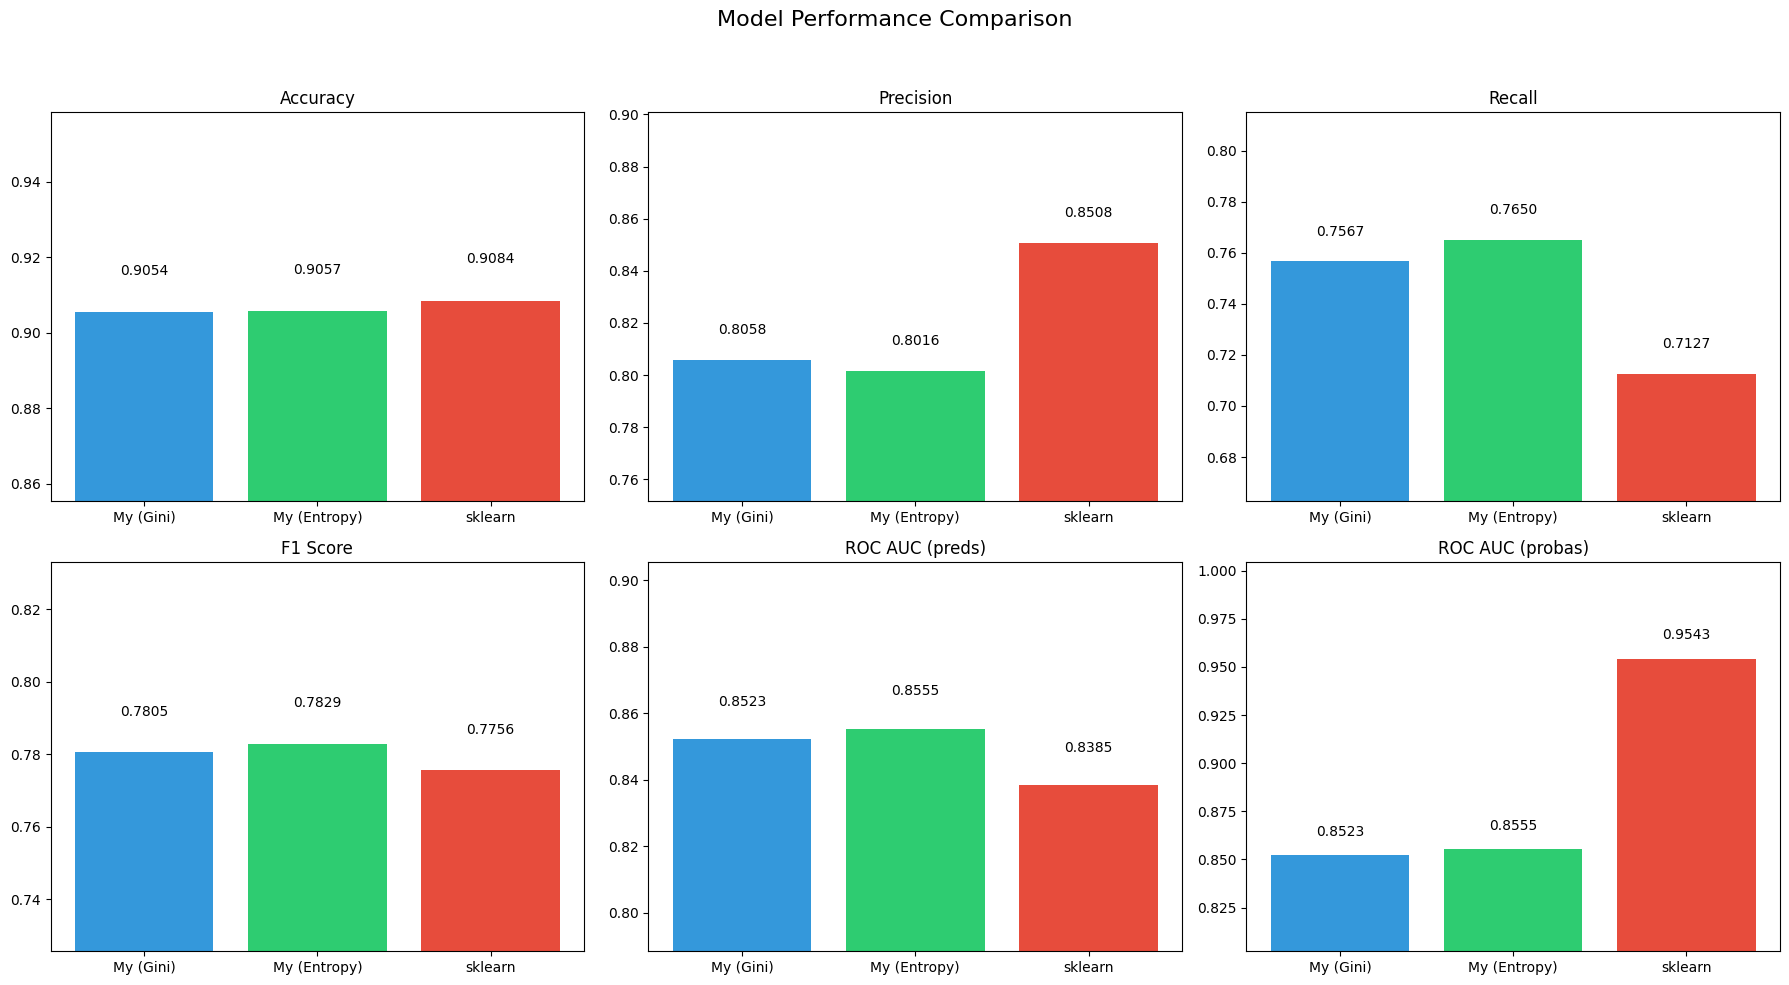

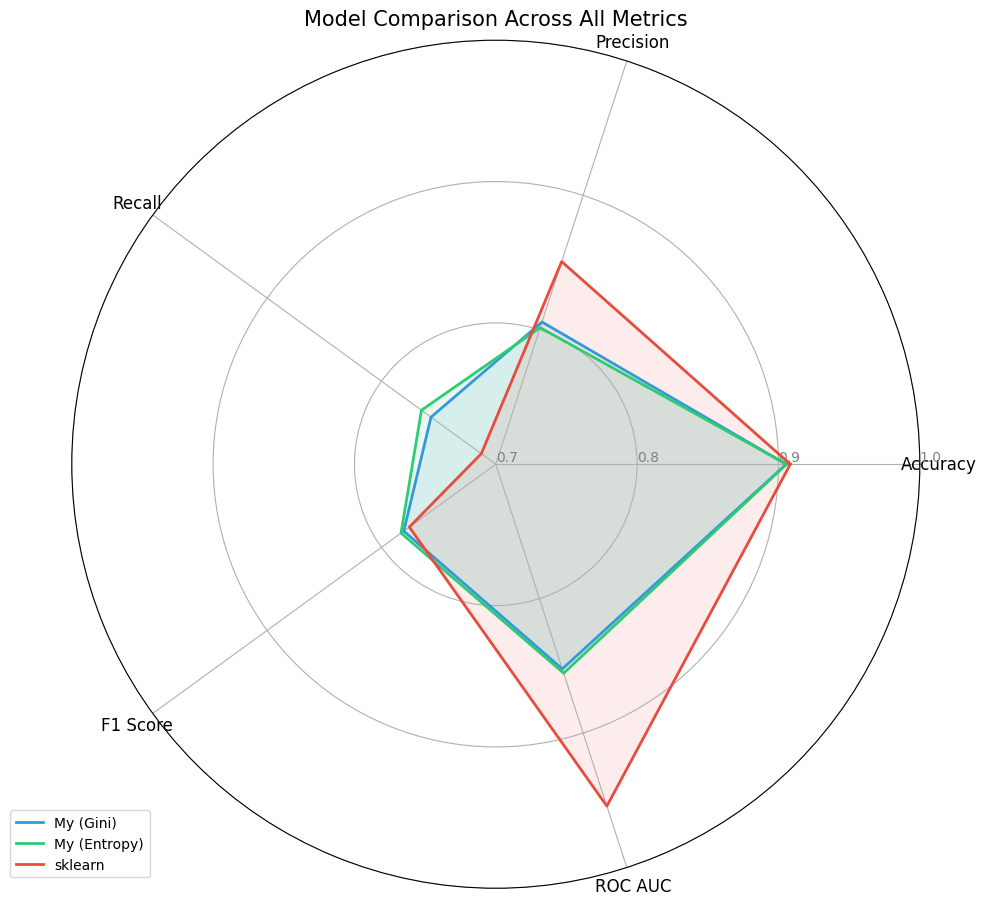

In [149]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Performance Comparison", fontsize=16)

axs = axs.flatten()

models = ["My (Gini)", "My (Entropy)", "sklearn"]

metrics = {
    "Accuracy": [
        gini_test_res["accuracy"],
        entropy_test_res["accuracy"],
        sk_test_res["accuracy"],
    ],
    "Precision": [
        gini_test_res["precision"],
        entropy_test_res["precision"],
        sk_test_res["precision"],
    ],
    "Recall": [
        gini_test_res["recall"],
        entropy_test_res["recall"],
        sk_test_res["recall"],
    ],
    "F1 Score": [
        gini_test_res["f1_score"],
        entropy_test_res["f1_score"],
        sk_test_res["f1_score"],
    ],
    "ROC AUC (preds)": [
        gini_test_res["roc_auc_preds"],
        entropy_test_res["roc_auc_preds"],
        sk_test_res["roc_auc_preds"],
    ],
    "ROC AUC (probas)": [
        gini_test_res["roc_auc_probas"],
        entropy_test_res["roc_auc_probas"],
        sk_test_res["roc_auc_probas"],
    ],
}

colors = ["#3498db", "#2ecc71", "#e74c3c"]

for i, (metric, values) in enumerate(metrics.items()):
    axs[i].bar(models, values, color=colors)
    axs[i].set_title(f"{metric}")
    axs[i].set_ylim(min(values) - 0.05, max(values) + 0.05)

    for j, v in enumerate(values):
        axs[i].text(j, v + 0.01, f"{v:.4f}", ha="center")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

metrics_for_radar = {
    "Accuracy": [
        gini_test_res["accuracy"],
        entropy_test_res["accuracy"],
        sk_test_res["accuracy"],
    ],
    "Precision": [
        gini_test_res["precision"],
        entropy_test_res["precision"],
        sk_test_res["precision"],
    ],
    "Recall": [
        gini_test_res["recall"],
        entropy_test_res["recall"],
        sk_test_res["recall"],
    ],
    "F1 Score": [
        gini_test_res["f1_score"],
        entropy_test_res["f1_score"],
        sk_test_res["f1_score"],
    ],
    "ROC AUC": [
        gini_test_res["roc_auc_probas"],
        entropy_test_res["roc_auc_probas"],
        sk_test_res["roc_auc_probas"],
    ],
}

categories = list(metrics_for_radar.keys())
N = len(categories)

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.xticks(angles[:-1], categories, size=12)

ax.set_rlabel_position(0)
plt.yticks([0.7, 0.8, 0.9, 1.0], ["0.7", "0.8", "0.9", "1.0"], color="grey", size=10)
plt.ylim(0.7, 1.0)

for i, model in enumerate(models):
    values = [metrics_for_radar[category][i] for category in categories]
    values += values[:1]
    ax.plot(
        angles, values, linewidth=2, linestyle="solid", label=model, color=colors[i]
    )
    ax.fill(angles, values, alpha=0.1, color=colors[i])

plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))

plt.title("Model Comparison Across All Metrics", size=15)
plt.tight_layout()
plt.show()